In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
from pathlib import Path
import numpy as np
import scipy as sp

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, auc, precision_recall_curve

from tqdm import tqdm
torch.manual_seed(1234)

gpu = "0"
device = torch.device(f"cuda:{gpu}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
batch_size = 16
dropout_mlp = 0.5
dropout_gru = 0.25
learning_rate = 1e-4
weight_decay = 1e-2

# os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"\
# os.environ['HF_HOME'] = "/path/to/hf_home"

Using device: cuda:0


In [2]:
# load train and test scores from /data
with open('data/only_answer/scores_fava_annot_open-llama-7b_layer21_500samp.pkl', 'rb') as f:
    scores, sample_indiv_scores, generated_embeddings, sample_labels = pickle.load(f)
    # scores, sample_indiv_scores, sample_labels = pickle.load(f)

/data/share/project/RSML/LLM_Check_Hallucination_Detection/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def get_roc_auc_scores(scores: np.array, labels: np.array):
    """
    Calculate ROC AUC metrics, including the AUC score, accuracy, and other key values.

    Args:
        scores (np.array): Predicted scores.
        labels (np.array): Ground Truth binary labels.

    Returns:
        tuple: A tuple containing the following:
            - arc (float): Area Under the Curve (AUC) for the Receiver Operating Characteristic (ROC) curve.
            - acc (float): Maximum accuracy derived from the ROC curve.
            - low (float): True Positive Rate (TPR) at the maximum False Positive Rate (FPR) < 0.05.
            - fpr (np.ndarray): False Positive Rates at various thresholds.
            - tpr (np.ndarray): True Positive Rates at various thresholds.
            - thresh_ind (int): Index of the threshold corresponding to maximum accuracy.
            - thresh (np.ndarray): Thresholds used for calculating the ROC curve.
    """
    fpr, tpr, thresh = roc_curve(labels, scores)
    precision, recall, thresholds = precision_recall_curve(labels, scores)
    
    # Calculate F1 score for each threshold, adding a small epsilon to avoid division by zero
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    # Find the index of the maximum F1 score
    optimal_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[optimal_idx]

    arc = auc(fpr, tpr)
    acc = np.max(1 - (fpr + (1 - tpr))/2)
    thresh_ind = np.argmax(1 - (fpr + (1 - tpr))/2)
    low = tpr[np.where(fpr<0.05)[0][-1]]
    return arc, acc, low, fpr, tpr, thresh_ind, thresh, best_f1


def get_thresh_val(thresh: np.array, acc: float, scores: np.array):
    """Find approx threshold that matches avg accuracy"""
    for t in thresh:
        pred_list = np.array([ 1 if x < t else 0 for x in scores])
        if np.mean(pred_list) <= acc:
            #print(f"Accuracy: {acc:.2f} , {np.mean(pred_list):.2f}")
            return t, pred_list

def get_balanced_scores(scores: np.array, sample_labels: np.array):
    """Get balanced scores"""
    num_samp = min(sum(sample_labels), len(sample_labels)-sum(sample_labels))
    bal_sc = np.concatenate([scores[:num_samp] , scores[-num_samp:]])
    bal_labels = np.concatenate([sample_labels[:num_samp], sample_labels[-num_samp:]])
    return bal_sc, bal_labels

In [4]:
# Ensure balanced dataset!
bal_sc, bal_labels = get_balanced_scores(scores, sample_labels)
len(bal_labels), sum(bal_labels)*2

(334, np.int64(334))

In [5]:
ly_scores = -np.array(sample_indiv_scores['logit']["perplexity"])
arc, acc, low, fpr, tpr, thresh_ind, thresh, f1 = get_roc_auc_scores(*get_balanced_scores(ly_scores,sample_labels))
# print(f"AUROC:{arc*100:.2f}, Acc:{acc*100:.2f}, TPR@5%FPR:{low*100:.2f}")
print(f"PPL & {arc*100:.2f} & {acc*100:.2f} & {low*100:.2f} & {f1*100:.2f} \\\\")

ly_scores = np.array(sample_indiv_scores['logit']["window_entropy"])
arc, acc, low, fpr, tpr, thresh_ind, thresh, f1 = get_roc_auc_scores(*get_balanced_scores(ly_scores,sample_labels))
print(f"Window Entropy & {arc*100:.2f} & {acc*100:.2f} & {low*100:.2f} & {f1*100:.2f} \\\\")

ly_scores = np.array(sample_indiv_scores['logit']["logit_entropy"])
arc, acc, low, fpr, tpr, thresh_ind, thresh, f1 = get_roc_auc_scores(*get_balanced_scores(ly_scores,sample_labels))
print(f"Logit Entropy & {arc*100:.2f} & {acc*100:.2f} & {low*100:.2f} & {f1*100:.2f} \\\\")

PPL & 49.44 & 55.39 & 2.99 & 67.82 \\
Window Entropy & 61.49 & 61.68 & 7.78 & 68.46 \\
Logit Entropy & 49.97 & 53.29 & 5.39 & 67.48 \\


Layer:2 - AUROC:0.6415, Acc:0.6257, TPR@5%FPR:0.1198, F1=0.6898
Layer:3 - AUROC:0.6018, Acc:0.6018, TPR@5%FPR:0.0599, F1=0.6895
Layer:4 - AUROC:0.6501, Acc:0.6287, TPR@5%FPR:0.0778, F1=0.6970
Layer:5 - AUROC:0.5921, Acc:0.5958, TPR@5%FPR:0.0958, F1=0.6749
Layer:6 - AUROC:0.6151, Acc:0.6138, TPR@5%FPR:0.0419, F1=0.6851
Layer:7 - AUROC:0.6246, Acc:0.6138, TPR@5%FPR:0.0838, F1=0.6872
Layer:8 - AUROC:0.6172, Acc:0.6048, TPR@5%FPR:0.0539, F1=0.6775
Layer:9 - AUROC:0.5285, Acc:0.5629, TPR@5%FPR:0.0539, F1=0.6756
Layer:10 - AUROC:0.5800, Acc:0.5928, TPR@5%FPR:0.0479, F1=0.6785
Layer:11 - AUROC:0.4772, Acc:0.5329, TPR@5%FPR:0.0120, F1=0.6747
Layer:12 - AUROC:0.5255, Acc:0.5539, TPR@5%FPR:0.0479, F1=0.6789
Layer:13 - AUROC:0.5340, Acc:0.5539, TPR@5%FPR:0.0539, F1=0.6747
Layer:14 - AUROC:0.4858, Acc:0.5449, TPR@5%FPR:0.0299, F1=0.6752
Layer:15 - AUROC:0.5001, Acc:0.5359, TPR@5%FPR:0.0539, F1=0.6775
Layer:16 - AUROC:0.5404, Acc:0.5689, TPR@5%FPR:0.0659, F1=0.6752
Layer:17 - AUROC:0.5692, Acc:0.58

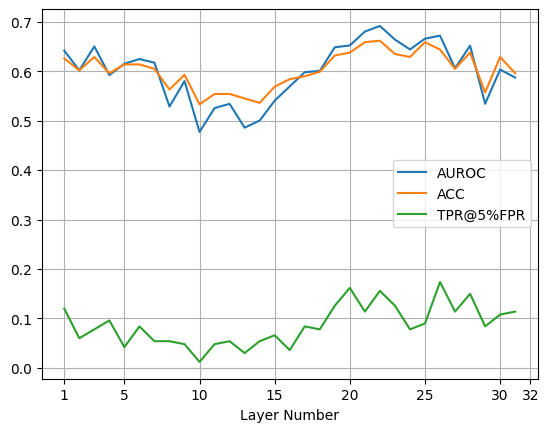

In [6]:
num_layers = len(sample_indiv_scores['attns'].keys())  # The 7B and 8B models that are being evaluated have 32 layers, so num_layers=31
arc_list, acc_list, low_list = [], [], []

samp_preds = []
thresh_vals = []

for layer_num in range(1, num_layers + 1):
    scores = -np.array(sample_indiv_scores['attns']["Attn"+str(layer_num)])
    bal_sc, bal_labels = get_balanced_scores(scores,sample_labels)
    arc, acc, low, fpr, tpr, thresh_ind, thresh, f1 = get_roc_auc_scores(bal_sc, bal_labels)
    thresh_val, pred_list = get_thresh_val(thresh, acc, bal_sc)
    samp_preds.append(pred_list)
    thresh_vals.append(thresh_val)
    print(f"Layer:{layer_num+1} - AUROC:{arc:.4f}, Acc:{acc:.4f}, TPR@5%FPR:{low:.4f}, F1={f1:.4f}")
    arc_list.append(arc)
    acc_list.append(acc)
    low_list.append(low)
    plt.plot(fpr, tpr, label = f'LY{layer_num}, AUC={arc*100:.2f}, Acc={acc*100:.2f}, TPR@5%FPR={low*100:.2f}') 

# print("Layer-wise results")
# print(arc_list)
# print(acc_list)
# print(low_list)

# # add the legend below the plot
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), shadow=True, ncol=2)
# plt.ylabel('True Positive Rate')
# plt.xlabel('False Positive Rate')
# plt.savefig("plots/llama_attns_layerwise_roc_var.png", dpi=200, bbox_inches='tight')

# clear the plot
plt.clf()
plt.xticks([1, 5, 10, 15, 20, 25, 30, 32])
plt.plot(range(1, len(arc_list) + 1), arc_list, label='AUROC')
plt.plot(range(1, len(arc_list) + 1), acc_list, label='ACC')
plt.plot(range(1, len(arc_list) + 1), low_list, label='TPR@5%FPR')
plt.xlabel('Layer Number')
plt.grid()
plt.legend()
plt.savefig("plots/llama_hidden_fava.png", dpi=200, bbox_inches='tight')
plt.show()


### Contextualized Embeddings

In [3]:
class FFHallucinationClassifier(torch.nn.Module):
    def __init__(self, input_shape, dropout = dropout_mlp):
        super().__init__()
        self.dropout = dropout
        
        self.linear_relu_stack = torch.nn.Sequential(
            torch.nn.Linear(input_shape, 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(self.dropout),
            torch.nn.Linear(256, 2)
            )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

In [4]:
def gen_classifier_roc(inputs, labels):
    X_train, X_test, y_train, y_test = train_test_split(inputs, labels, test_size=0.2, random_state=123)
    classifier_model = FFHallucinationClassifier(X_train.shape[1]).to(device)
    X_train = torch.tensor(X_train).to(device)
    y_train = torch.tensor(y_train).to(torch.long).to(device)
    X_test = torch.tensor(X_test).to(device)
    y_test = torch.tensor(y_test).to(torch.long).to(device)

    optimizer = torch.optim.AdamW(classifier_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    for _ in tqdm(range(1001)):
        optimizer.zero_grad()
        sample = torch.randperm(X_train.shape[0])[:batch_size]
        pred = classifier_model(X_train[sample])
        loss = torch.nn.functional.cross_entropy(pred, y_train[sample])
        loss.backward()
        optimizer.step()
    classifier_model.eval()
    with torch.no_grad():
        pred = torch.nn.functional.softmax(classifier_model(X_test), dim=1)
        prediction_classes = (pred[:,1]>0.5).type(torch.long).cpu()
        y_score = pred[:,1].cpu().numpy()
        y_true = y_test.cpu().numpy()
        roc_auc = roc_auc_score(y_true, y_score)
        acc = (prediction_classes.numpy()==y_test.cpu().numpy()).mean()
        f1 = f1_score(y_true, prediction_classes)
        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        tpr_at_5_fpr = np.interp(0.05, fpr, tpr)
    return roc_auc, acc, tpr_at_5_fpr, f1

In [5]:
pooled_embeddings = []
for i in range(len(generated_embeddings)):
    embeddings = generated_embeddings[i]
    emb_sequence = torch.tensor(embeddings, dtype=torch.float32)
    # pooled_emb = torch.mean(emb_sequence, dim=0)
    pooled_emb = torch.max(emb_sequence, dim=0).values
    pooled_embeddings.append(pooled_emb)

pooled_embeddings_tensor = torch.stack(pooled_embeddings)
print(pooled_embeddings_tensor[0].shape)
context_emb_roc, context_emb_acc, context_emb_tpr_at_5_fpr, context_emb_f1 = gen_classifier_roc(pooled_embeddings_tensor, sample_labels)

/tmp/ipykernel_1020803/2833087188.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  emb_sequence = torch.tensor(embeddings, dtype=torch.float32)


torch.Size([4096])


/tmp/ipykernel_1020803/4185729829.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test).to(device)
100%|██████████| 1001/1001 [00:03<00:00, 295.07it/s]


In [6]:
print(f"Contextual Embeddings - AUROC: {context_emb_roc:.4f}, Accuracy: {context_emb_acc:.4f}")
print(f"f1_score: {context_emb_f1:.4f}")
print(f"TPR at 5% FPR: {context_emb_tpr_at_5_fpr:.4f}")

Contextual Embeddings - AUROC: 0.6448, Accuracy: 0.6848
f1_score: 0.8105
TPR at 5% FPR: 0.2698


### 3-layer DNN + Residual Block

In [7]:
class ResidualBlock(torch.nn.Module):
    def __init__(self, hidden_dim):
        super(ResidualBlock, self).__init__()
        self.fc1 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.relu = torch.nn.ReLU()
        # self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        identity = x
        
        out = self.fc1(x)
        # out = self.relu(out)
        # out = self.fc2(out)
        
        out = out + identity
        out = self.relu(out)
        
        return out

class DNNClassifier(torch.nn.Module):
    def __init__(self, input_size, hidden_size=256):
        super(DNNClassifier, self).__init__()
        
        self.layer1 = torch.nn.Linear(input_size, hidden_size)
        self.relu = torch.nn.ReLU()

        self.res_block = ResidualBlock(hidden_size)

        self.layer3 = torch.nn.Linear(hidden_size, 2)
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        
        x = self.res_block(x)

        x = self.layer3(x)
        
        return x

In [8]:
def gen_classifier_roc(inputs, labels):
    X_train, X_test, y_train, y_test = train_test_split(inputs, labels, test_size=0.2, random_state=123)
    classifier_model = DNNClassifier(X_train.shape[1]).to(device)
    X_train = torch.tensor(X_train).to(device)
    y_train = torch.tensor(y_train).to(torch.long).to(device)
    X_test = torch.tensor(X_test).to(device)
    y_test = torch.tensor(y_test).to(torch.long).to(device)

    optimizer = torch.optim.AdamW(classifier_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    for _ in tqdm(range(1001)):
        optimizer.zero_grad()
        sample = torch.randperm(X_train.shape[0])[:batch_size]
        pred = classifier_model(X_train[sample])
        loss = torch.nn.functional.cross_entropy(pred, y_train[sample])
        loss.backward()
        optimizer.step()
    classifier_model.eval()
    with torch.no_grad():
        pred = torch.nn.functional.softmax(classifier_model(X_test), dim=1)
        prediction_classes = (pred[:,1]>0.5).type(torch.long).cpu()
        y_score = pred[:,1].cpu().numpy()
        y_true = y_test.cpu().numpy()
        roc_auc = roc_auc_score(y_true, y_score)
        acc = (prediction_classes.numpy()==y_test.cpu().numpy()).mean()
        f1 = f1_score(y_true, prediction_classes)
        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        tpr_at_5_fpr = np.interp(0.05, fpr, tpr)
        return roc_auc, acc, tpr_at_5_fpr, f1

In [9]:
pooled_embeddings = []
for i in range(len(generated_embeddings)):
    embeddings = generated_embeddings[i]
    emb_sequence = torch.tensor(embeddings, dtype=torch.float32)
    pooled_emb = torch.mean(emb_sequence, dim=0)
    pooled_embeddings.append(pooled_emb)

pooled_embeddings_tensor = torch.stack(pooled_embeddings)
context_emb_roc, context_emb_acc, context_emb_tpr_at_5_fpr, context_emb_f1 = gen_classifier_roc(pooled_embeddings_tensor, sample_labels)

/tmp/ipykernel_1018669/1214628917.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  emb_sequence = torch.tensor(embeddings, dtype=torch.float32)
/tmp/ipykernel_1018669/1136257659.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test).to(device)
100%|██████████| 1001/1001 [00:03<00:00, 325.26it/s]


In [10]:
print(f"Contextual Embeddings - AUROC: {context_emb_roc:.4f}, Accuracy: {context_emb_acc:.4f}")
print(f"f1_score: {context_emb_f1:.4f}")
print(f"TPR at 5% FPR: {context_emb_tpr_at_5_fpr:.4f}")

Contextual Embeddings - AUROC: 0.6847, Accuracy: 0.6522
f1_score: 0.7460
TPR at 5% FPR: 0.3175
